In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [96]:
data = pd.read_csv("/kaggle/input/datasets/rashadrmammadov/heart-disease-prediction/heart_disease_dataset.csv")

print(data)
print("Rows:", data.shape[0])
print("Coulmns:", data.shape[1])

     Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0     75  Female          228             119          66  Current   
1     48    Male          204             165          62  Current   
2     53    Male          234              91          67    Never   
3     69  Female          192              90          72  Current   
4     62  Female          172             163          93    Never   
..   ...     ...          ...             ...         ...      ...   
995   56  Female          269             111          86    Never   
996   78  Female          334             145          76    Never   
997   79    Male          151             179          81    Never   
998   60  Female          326             151          68   Former   
999   53    Male          226             116          82  Current   

    Alcohol Intake  Exercise Hours Family History Diabetes Obesity  \
0            Heavy               1             No       No     Yes   
1              NaN 

In [97]:
data1 = data.copy()

data1.loc[data1.loc[:,"Alcohol Intake"].isna(), "Alcohol Intake"] = "Never"
print(data1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           1000 non-null   object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [98]:
data.isnull().sum()


Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

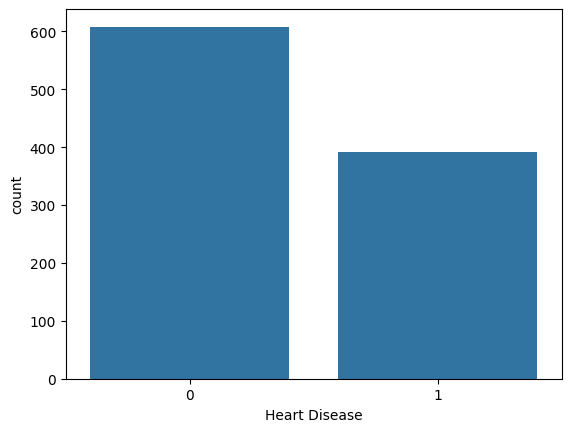

In [99]:
sns.countplot(x='Heart Disease', data=data)
plt.show()

In [100]:
model_params = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Key Parameters': 'penalty=l2, C=1.0, solver=lbfgs, max_iter=100 (all defaults)'},
    {'Model': 'Decision Tree', 'Key Parameters': 'criterion=gini, max_depth=None, random_state=42'},
    {'Model': 'Random Forest', 'Key Parameters': 'n_estimators=100, max_depth=None, random_state=42'},
    {'Model': 'SVM', 'Key Parameters': 'kernel=rbf, C=1.0, gamma=scale, probability=True'},
    {'Model': 'KNN', 'Key Parameters': 'n_neighbors=5, weights=uniform, metric=minkowski (p=2)'}
])
model_params

,Model,Key Parameters
0,Logistic Regression,"penalty=l2, C=1.0, solver=lbfgs, max_iter=100 ..."
1,Decision Tree,"criterion=gini, max_depth=None, random_state=42"
2,Random Forest,"n_estimators=100, max_depth=None, random_state=42"
3,SVM,"kernel=rbf, C=1.0, gamma=scale, probability=True"
4,KNN,"n_neighbors=5, weights=uniform, metric=minkows..."


In [101]:
import pandas as pd

data = data1

In [102]:
data.isnull().sum()

Age                        0
Gender                     0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Smoking                    0
Alcohol Intake             0
Exercise Hours             0
Family History             0
Diabetes                   0
Obesity                    0
Stress Level               0
Blood Sugar                0
Exercise Induced Angina    0
Chest Pain Type            0
Heart Disease              0
dtype: int64

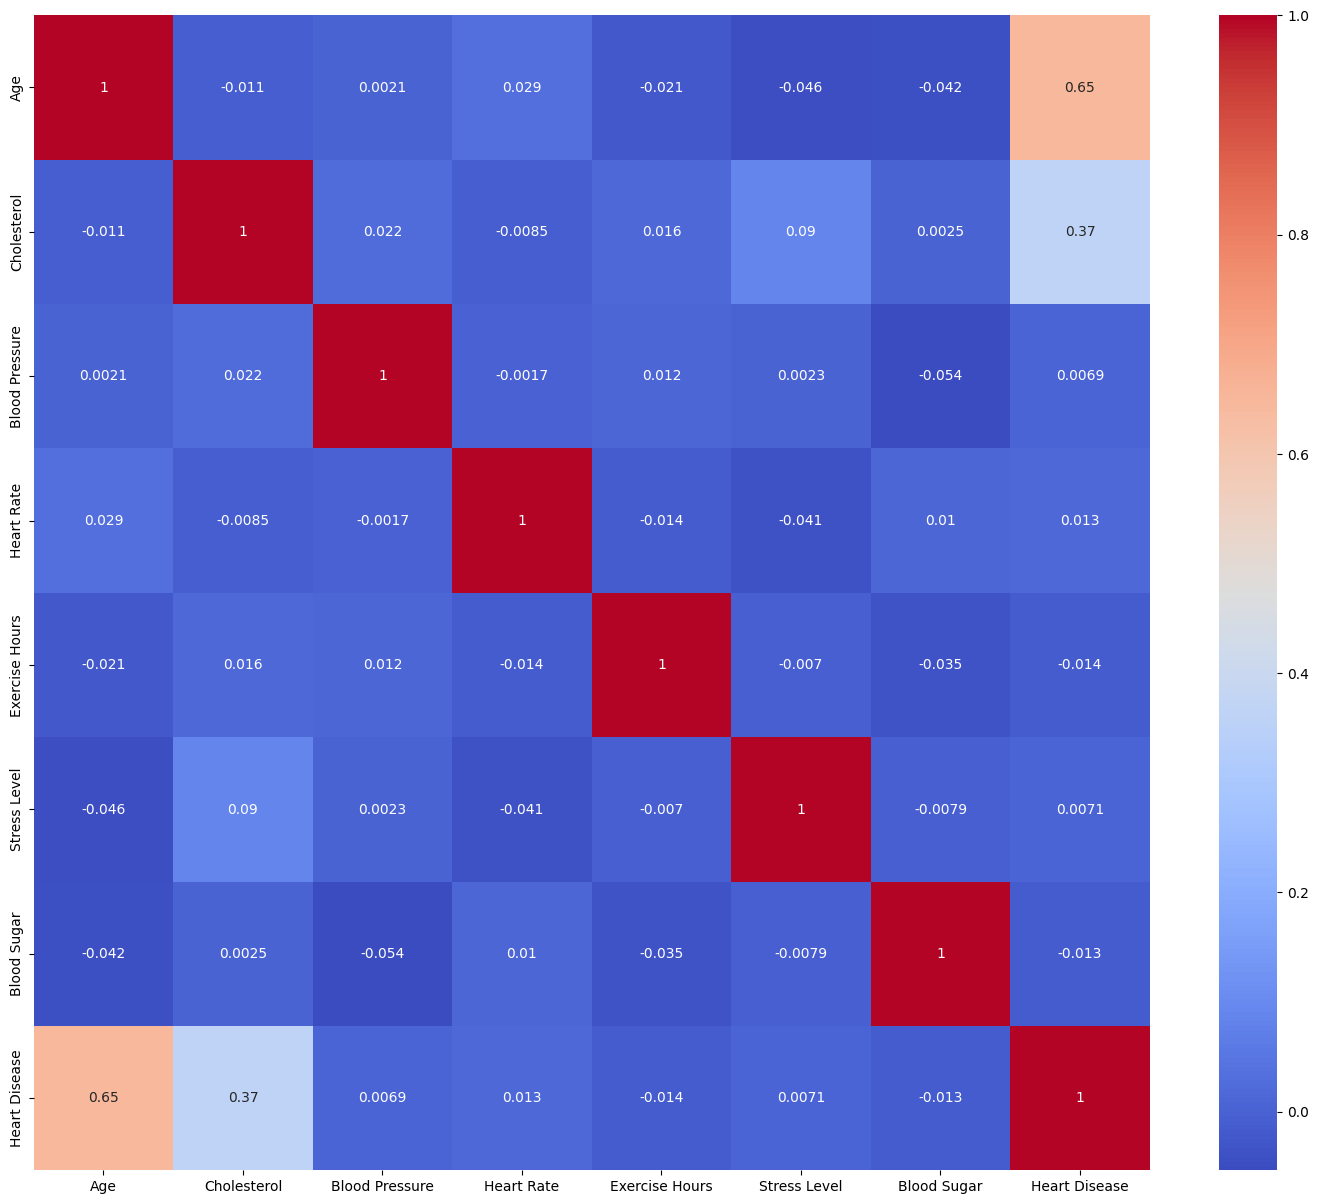

In [103]:
plt.figure(figsize=(18,15))
sns.heatmap( data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm' )
plt.show()

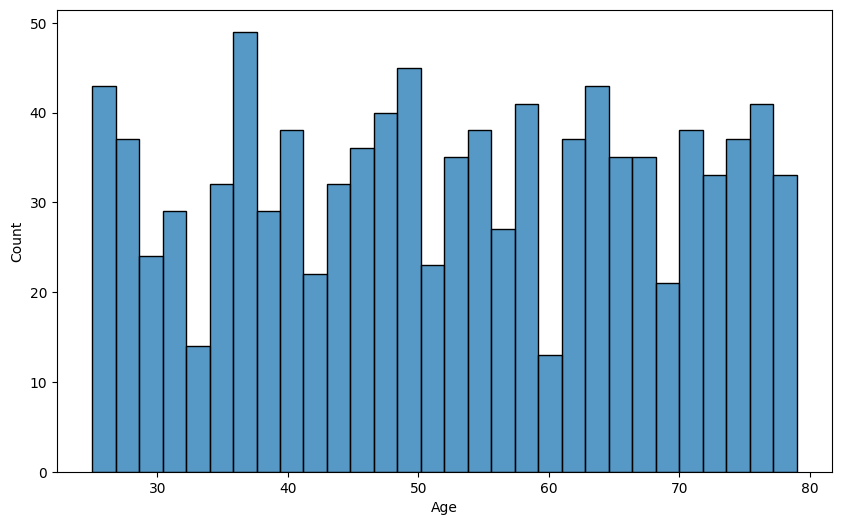

In [104]:
plt.figure(figsize=(10,6))
sns.histplot(data['Age'], bins=30)
plt.show()

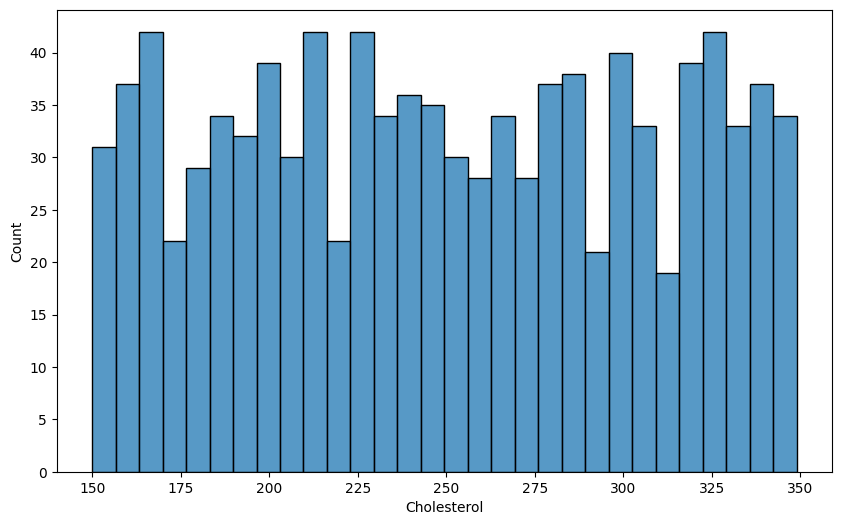

In [105]:
plt.figure(figsize=(10,6))
sns.histplot(data['Cholesterol'], bins=30)
plt.show()

In [106]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object': 
        data[column] = label_encoder.fit_transform(data[column])

In [107]:
data.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,0,228,119,66,0,0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,0,2,5,0,0,0,9,70,1,3,0
2,53,1,234,91,67,2,0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,0,2,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,2,2,6,0,1,0,2,183,1,0,0


In [108]:
X = data.drop('Heart Disease', axis=1) 
y = data['Heart Disease']

In [109]:
clinical_cols = ['Cholesterol', 'Blood Pressure', 'Heart Rate', 'Blood Sugar',
                  'Chest Pain Type', 'Exercise Induced Angina', 'Diabetes',
                  'Family History', 'Obesity']
lifestyle_cols = ['Smoking', 'Alcohol Intake', 'Exercise Hours', 'Stress Level']
demographic_cols = ['Age', 'Gender']

def evaluate_subset(cols, label):
    X_sub = data[cols]
    X_sub_scaled = StandardScaler().fit_transform(X_sub)
    Xtr, Xte, ytr, yte = train_test_split(X_sub_scaled, y, test_size=0.2, random_state=35)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:,1]
    return {
        'Feature Set': label,
        'Accuracy': accuracy_score(yte, pred),
        'Recall': recall_score(yte, pred),
        'ROC-AUC': roc_auc_score(yte, prob)
    }

subset_results = pd.DataFrame([
    evaluate_subset(clinical_cols, 'Clinical Factors Only'),
    evaluate_subset(lifestyle_cols, 'Lifestyle Factors Only'),
    evaluate_subset(demographic_cols, 'Demographic Factors Only'),
    evaluate_subset(clinical_cols + lifestyle_cols + demographic_cols, 'All Factors Combined')
])
subset_results

,Feature Set,Accuracy,Recall,ROC-AUC
0,Clinical Factors Only,0.605,0.417722,0.680877
1,Lifestyle Factors Only,0.555,0.417722,0.508892
2,Demographic Factors Only,0.845,1.000000,0.871430
3,All Factors Combined,0.995,0.987342,1.000000


In [110]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [111]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

models_for_cv = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

cv_results = []
for name, model in models_for_cv.items():
    scores = cross_validate(model, X_scaled, y, cv=cv, scoring=scoring)
    cv_results.append({
        'Model': name,
        'CV Accuracy (mean ± std)': f"{scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}",
        'CV Precision (mean ± std)': f"{scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}",
        'CV Recall (mean ± std)': f"{scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}",
        'CV F1 (mean ± std)': f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}",
        'CV ROC-AUC (mean ± std)': f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,CV Accuracy (mean ± std),CV Precision (mean ± std),CV Recall (mean ± std),CV F1 (mean ± std),CV ROC-AUC (mean ± std)
0,Logistic Regression,0.859 ± 0.025,0.821 ± 0.024,0.819 ± 0.046,0.820 ± 0.034,0.946 ± 0.012
1,Decision Tree,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
2,Random Forest,0.998 ± 0.002,1.000 ± 0.000,0.995 ± 0.006,0.997 ± 0.003,1.000 ± 0.000
3,SVM,0.906 ± 0.030,0.904 ± 0.047,0.852 ± 0.037,0.877 ± 0.040,0.969 ± 0.010
4,KNN,0.772 ± 0.021,0.724 ± 0.030,0.676 ± 0.033,0.699 ± 0.030,0.837 ± 0.014


In [112]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2, 
    random_state=35 )

In [113]:
from sklearn.linear_model import LogisticRegression
lreg = LogisticRegression()

lreg.fit(X_train, y_train)

lreg_pred = lreg.predict(X_test)

lreg_prob = lreg.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, lreg_pred))
print("Precision:", precision_score(y_test, lreg_pred))
print("Recall   :", recall_score(y_test, lreg_pred))
print("F1 Score :", f1_score(y_test, lreg_pred))
print("ROC AUC  :", roc_auc_score(y_test, lreg_prob))
print(classification_report(y_test, lreg_pred))

Accuracy : 0.86
Precision: 0.7931034482758621
Recall   : 0.8734177215189873
F1 Score : 0.8313253012048193
ROC AUC  : 0.9504132231404959
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       121
           1       0.79      0.87      0.83        79

    accuracy                           0.86       200
   macro avg       0.85      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



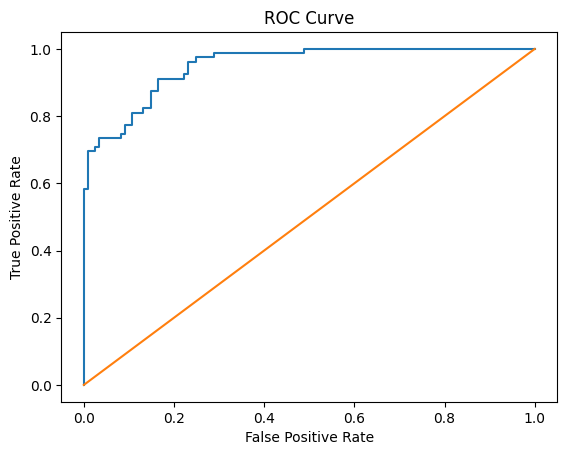

In [114]:
fpr, tpr, threshold = roc_curve(y_test, lreg_prob)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='-')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [115]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC AUC  :", roc_auc_score(y_test, dt_prob))
print(classification_report(y_test, dt_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00        79

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



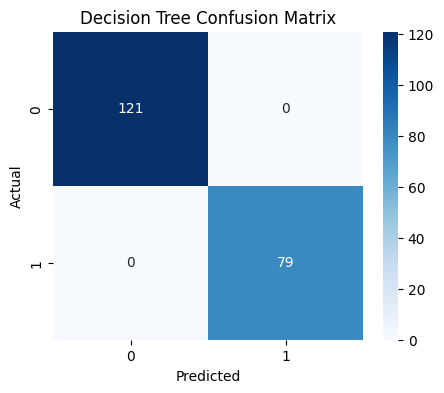

In [116]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

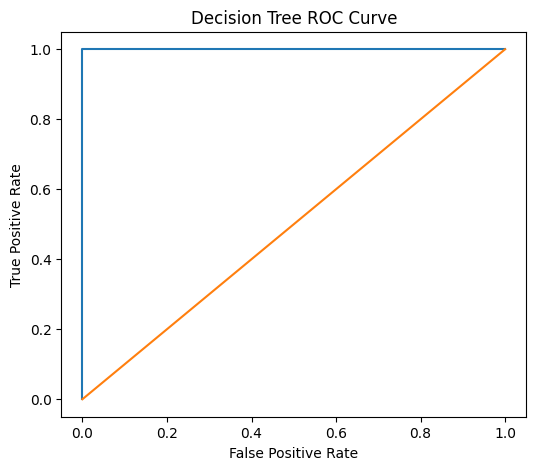

In [117]:
fpr, tpr, threshold = roc_curve(y_test, dt_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='-')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC Curve")

plt.show()

In [118]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00        79

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



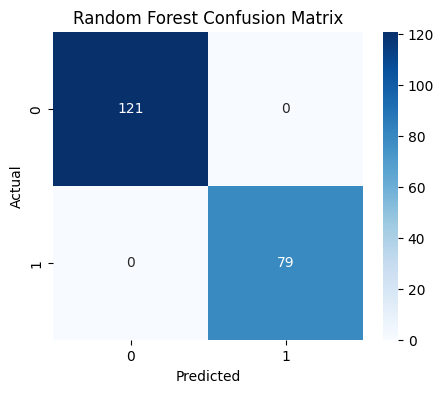

In [119]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

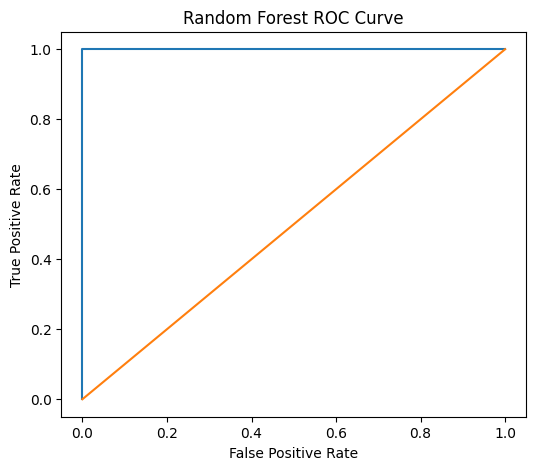

In [120]:
fpr, tpr, threshold = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='-')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.show()

Overlapping rows between train and test: 0
Accuracy using ONLY Age + Cholesterol, depth-2 tree: 1.0


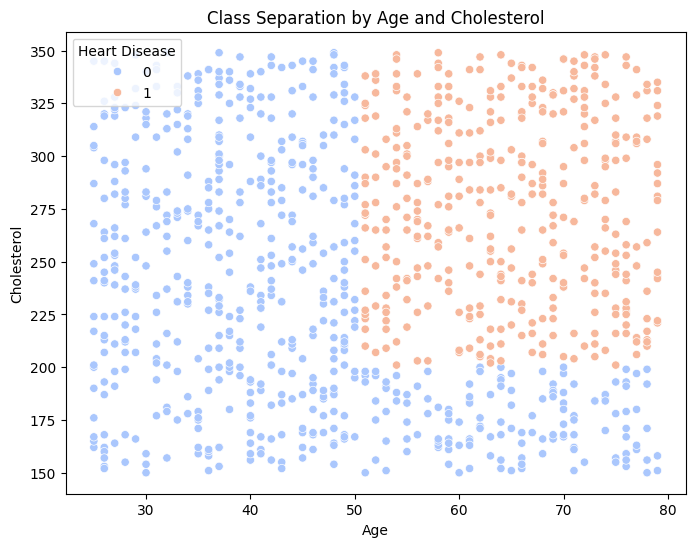

In [121]:

train_df = pd.DataFrame(X_train, columns=X.columns)
test_df = pd.DataFrame(X_test, columns=X.columns)
overlap = pd.merge(train_df, test_df, how='inner')
print("Overlapping rows between train and test:", len(overlap))
from sklearn.tree import DecisionTreeClassifier
X_top2 = data[['Age', 'Cholesterol']]
X_top2_scaled = scaler.fit_transform(X_top2)
Xtr2, Xte2, ytr2, yte2 = train_test_split(X_top2_scaled, y, test_size=0.2, random_state=35)
shallow_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
shallow_tree.fit(Xtr2, ytr2)
print("Accuracy using ONLY Age + Cholesterol, depth-2 tree:",
      accuracy_score(yte2, shallow_tree.predict(Xte2)))
plt.figure(figsize=(8,6))
sns.scatterplot(x=data['Age'], y=data['Cholesterol'], hue=data['Heart Disease'], palette='coolwarm')
plt.title("Class Separation by Age and Cholesterol")
plt.show()

In [122]:
from sklearn.svm import SVC
svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_prob = svm.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))
print("ROC AUC  :", roc_auc_score(y_test, svm_prob))
print(classification_report(y_test, svm_pred))

Accuracy : 0.915
Precision: 0.8690476190476191
Recall   : 0.9240506329113924
F1 Score : 0.8957055214723927
ROC AUC  : 0.9700805523590333
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       121
           1       0.87      0.92      0.90        79

    accuracy                           0.92       200
   macro avg       0.91      0.92      0.91       200
weighted avg       0.92      0.92      0.92       200



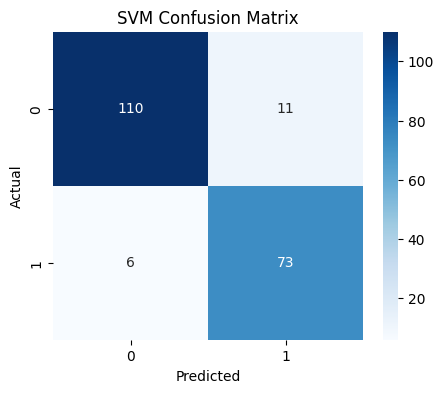

In [123]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

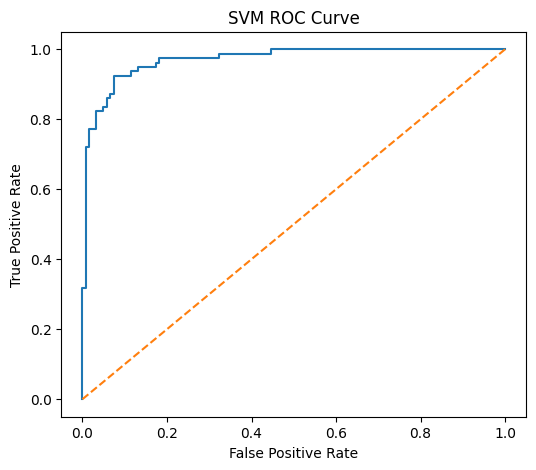

In [124]:
fpr, tpr, threshold = roc_curve(y_test, svm_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("SVM ROC Curve")

plt.show()

In [125]:
from sklearn.neighbors import KNeighborsClassifier 
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_prob = knn.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))
print("ROC AUC  :", roc_auc_score(y_test, knn_prob))

Accuracy : 0.815
Precision: 0.7333333333333333
Recall   : 0.8354430379746836
F1 Score : 0.7810650887573964
ROC AUC  : 0.8691808766607385


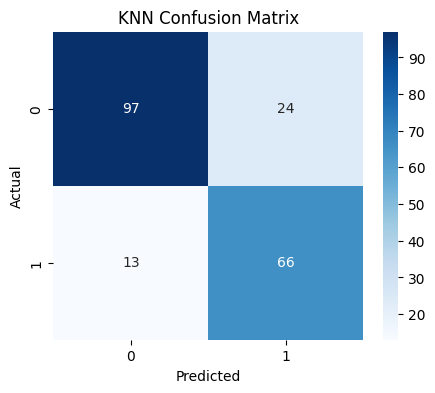

In [126]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

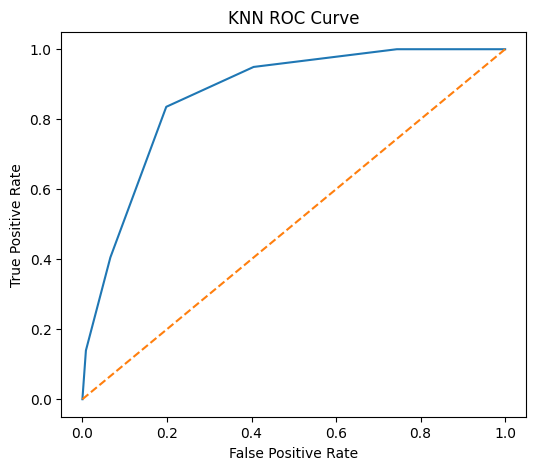

In [127]:
fpr, tpr, threshold = roc_curve(y_test, knn_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("KNN ROC Curve")

plt.show()

In [128]:
results = pd.DataFrame({ 'Model':
                        [ 'Logistic Regression', 
                         'Decision Tree',
                         'Random Forest',
                         'SVM', 
                         'KNN'
                        ],
                        'Accuracy':
                        [ accuracy_score(y_test, lreg_pred),
                         accuracy_score(y_test, dt_pred),
                         accuracy_score(y_test, rf_pred),
                         accuracy_score(y_test, svm_pred),
                         accuracy_score(y_test, knn_pred)
                        ]
                        }) 
results

,Model,Accuracy
0,Logistic Regression,0.860
1,Decision Tree,1.000
2,Random Forest,1.000
3,SVM,0.915
4,KNN,0.815


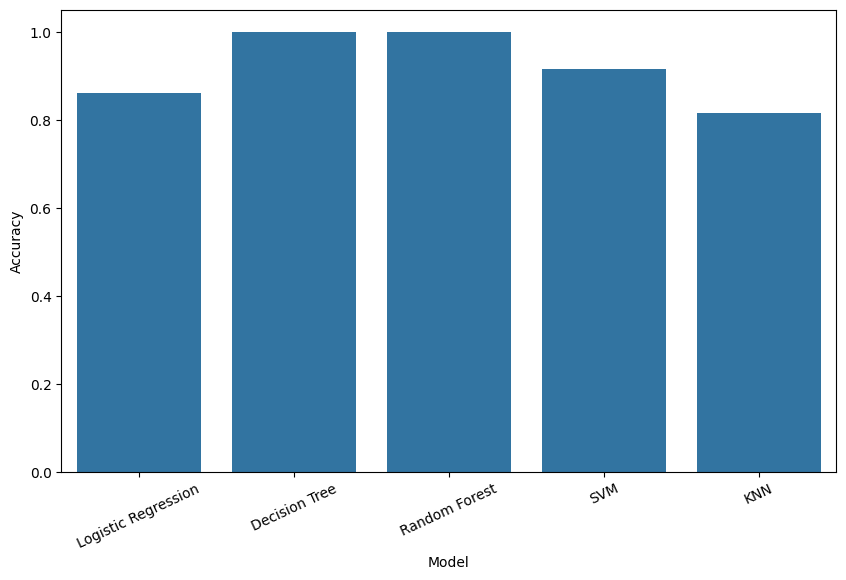

In [129]:
from sklearn.metrics import accuracy_score 
plt.figure(figsize=(10,6))
sns.barplot( x='Model', y='Accuracy', data=results )
plt.xticks(rotation=25)
plt.show()

In [130]:

importance = rf.feature_importances_ 
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance 
})
feature_importance = feature_importance.sort_values( by='Importance', ascending=False )
feature_importance

,Feature,Importance
0,Age,0.532414
2,Cholesterol,0.259704
3,Blood Pressure,0.036051
12,Blood Sugar,0.034531
4,Heart Rate,0.029899
7,Exercise Hours,0.021946
11,Stress Level,0.021663
14,Chest Pain Type,0.014173
5,Smoking,0.010758
6,Alcohol Intake,0.010253


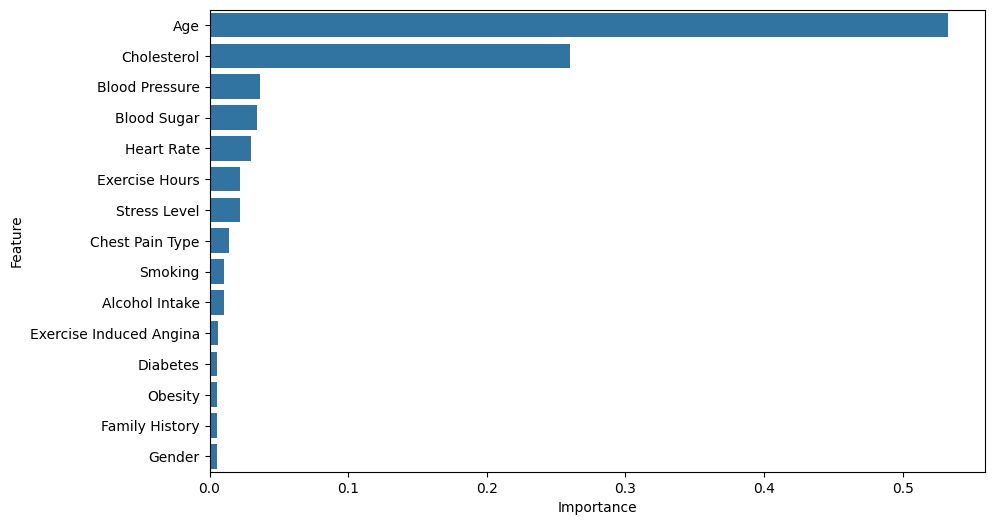

In [131]:
plt.figure(figsize=(10,6))
sns.barplot( x='Importance', y='Feature', data=feature_importance )
plt.show()

In [132]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [133]:
import joblib
joblib.dump(rf, 'heart_disease_model.pkl')

['heart_disease_model.pkl']

In [134]:
loaded_model = joblib.load('heart_disease_model.pkl')

In [135]:
sample = X_test[19].reshape(1,-1)
prediction = loaded_model.predict(sample)
print(prediction)

[1]


In [136]:

patient_data = [[
    58,
    1,
    240,
    150,
    95,
    0,
    1,
    1,
    1,
    0,
    1,
    8,
    180,
    1,
    2
]]

patient_df = pd.DataFrame(
    patient_data,
    columns=X.columns
)

print("PATIENT DETAILS")
print(patient_df)

patient_scaled = scaler.transform(patient_df.values)

prediction = loaded_model.predict(patient_scaled)

probability = loaded_model.predict_proba(patient_scaled)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

print("\nPrediction Probability:")
print(probability)



PATIENT DETAILS
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   58       1          240             150          95        0   

   Alcohol Intake  Exercise Hours  Family History  Diabetes  Obesity  \
0               1               1               1         0        1   

   Stress Level  Blood Sugar  Exercise Induced Angina  Chest Pain Type  
0             8          180                        1                2  

Prediction Result:
Heart Disease Detected

Prediction Probability:
[[0.11 0.89]]


In [137]:

patient_data = [[
    28,
    1,
    120,
    120,
    76,
    0,
    0,
    1,
    0,
    0,
    0,
    4,
    110,
    1,
    0
]]

patient_df = pd.DataFrame(
    patient_data,
    columns=X.columns
)

print("PATIENT DETAILS")
print(patient_df)

patient_scaled = scaler.transform(patient_df.values)

prediction = loaded_model.predict(patient_scaled)

probability = loaded_model.predict_proba(patient_scaled)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

print("\nPrediction Probability:")
print(probability)



PATIENT DETAILS
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   28       1          120             120          76        0   

   Alcohol Intake  Exercise Hours  Family History  Diabetes  Obesity  \
0               0               1               0         0        0   

   Stress Level  Blood Sugar  Exercise Induced Angina  Chest Pain Type  
0             4          110                        1                0  

Prediction Result:
No Heart Disease Detected

Prediction Probability:
[[1. 0.]]


In [138]:

patient_data = [[
    78,
    0,
    250,
    180,
    96,
    0,
    1,
    1,
    0,
    1,
    0,
    9,
    160,
    1,
    3
]]

patient_df = pd.DataFrame(
    patient_data,
    columns=X.columns
)

print("PATIENT DETAILS")
print(patient_df)

patient_scaled = scaler.transform(patient_df.values)

prediction = loaded_model.predict(patient_scaled)

probability = loaded_model.predict_proba(patient_scaled)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

print("\nPrediction Probability:")
print(probability)



PATIENT DETAILS
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   78       0          250             180          96        0   

   Alcohol Intake  Exercise Hours  Family History  Diabetes  Obesity  \
0               1               1               0         1        0   

   Stress Level  Blood Sugar  Exercise Induced Angina  Chest Pain Type  
0             9          160                        1                3  

Prediction Result:
Heart Disease Detected

Prediction Probability:
[[0.15 0.85]]
